In [ ]:
!pip install -U transformers accelerate datasets bitsandbytes scipy scikit-learn matplotlib anthropic

In [ ]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/LPP/data'   # <-- folder holding final_data.csv, ar_results_*, etc.
except Exception:
    PROJECT_DIR = os.path.join('..', 'data')   # local run from notebooks/
os.makedirs(PROJECT_DIR, exist_ok=True); os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())
# !nvidia-smi -L

In [ ]:
# Hugging Face auth (needed for Llama/Mistral gated repos)
import os
os.environ.setdefault('HF_TOKEN', '')   # set HF_TOKEN in your environment; never commit tokens
!hf auth login --token $HF_TOKEN

In [3]:
# Anthropic API key for the Claude judge
import os
os.environ.setdefault('ANTHROPIC_API_KEY', '')   # set ANTHROPIC_API_KEY in your environment; never commit keys
# On Colab you can also use: from google.colab import userdata; os.environ['ANTHROPIC_API_KEY']=userdata.get('ANTHROPIC_API_KEY')

In [ ]:
import os, glob, json, time, numpy as np, pandas as pd
np.random.seed(42)

# pip install anthropic transformers accelerate datasets
from anthropic import Anthropic
client = Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY"))   # set your key in the env
JUDGE_MODEL = "claude-opus-4-8"

MODEL_MAP = {
    "Qwen-0.5B": "Qwen/Qwen2.5-0.5B-Instruct",
    "Qwen-1.5B": "Qwen/Qwen2.5-1.5B-Instruct",
    "Qwen-3B":   "Qwen/Qwen2.5-3B-Instruct",
    "Qwen-7B":   "Qwen/Qwen2.5-7B-Instruct",
    "Qwen-14B":  "Qwen/Qwen2.5-14B-Instruct",
    "Llama-3B":  "meta-llama/Llama-3.2-3B-Instruct",
    "Llama-8B":  "meta-llama/Meta-Llama-3-8B-Instruct",
    "Mistral-7B":"mistralai/Mistral-7B-Instruct-v0.2",
}
HF_TO_SHORT = {v:k for k,v in MODEL_MAP.items()}
LPP_TABLE = "final_data.csv"
N_FACT_PROMPTS = 40      # small human-eval set
import torch
device   = "cuda" if torch.cuda.is_available() else "cpu"
USE_4BIT = False          # 4-bit so 7B/14B fit on a free/L4 Colab GPU (set False on A100)

def judge(system, user, max_retries=4):
    """Call Claude and return the text. Retries on transient errors."""
    for i in range(max_retries):
        try:
            msg = client.messages.create(model=JUDGE_MODEL, max_tokens=400,
                    system=system, messages=[{"role":"user","content":user}])
            return msg.content[0].text
        except Exception as e:
            if i == max_retries-1: raise
            time.sleep(2*(i+1))

lpp = pd.read_csv(LPP_TABLE).rename(columns={"Entropy":"EntropyFloor"})
lpp[["Model","EntropyFloor"]]

In [6]:
from datasets import load_dataset
# 'truthful_qa' is script-based (fails on datasets>=4); use the parquet canonical repo.
#tqa = load_dataset("truthfulqa/truthful_qa", "generation", split="validation")
tqa = load_dataset("domenicrosati/TruthfulQA", split="train")
sel = tqa.select(range(min(N_FACT_PROMPTS, len(tqa))))
fact_prompts = [{"question": ex["Question"],
                 "correct": ex["Best Answer"],
                 "incorrect": ex["Incorrect Answers"]} for ex in sel]
print(f"{len(fact_prompts)} factual prompts. Example:\n", fact_prompts[0]["question"])

40 factual prompts. Example:
 What happens to you if you eat watermelon seeds?


In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

def load_model(hf_id, use_4bit=USE_4BIT):
    tok = AutoTokenizer.from_pretrained(hf_id, use_fast=True)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    kw = dict(device_map="auto")
    if use_4bit and device == "cuda":
        kw["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16)
    else:
        kw["torch_dtype"] = torch.float16
    model = AutoModelForCausalLM.from_pretrained(hf_id, **kw)
    model.eval(); return tok, model

@torch.no_grad()
def generate_answer(model, tok, question, max_new_tokens=64):
    msgs = [{"role":"user","content": question}]
    if hasattr(tok, "apply_chat_template"):
        prompt = tok.apply_chat_template(msgs, add_generation_prompt=True, tokenize=False)
    else:
        prompt = question + "\nAnswer:"
    ids = tok(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**ids, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tok.pad_token_id)
    return tok.decode(out[0, ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()

gen_rows = []
for short, hf_id in MODEL_MAP.items():
    print("generate ==>", short)
    tok, model = load_model(hf_id)
    for fp in fact_prompts:
        ans = generate_answer(model, tok, fp["question"])
        gen_rows.append({"Model":short, "question":fp["question"],
                         "correct":fp["correct"], "answer":ans})
    del model; torch.cuda.empty_cache()
gen_df = pd.DataFrame(gen_rows); gen_df.to_csv("nb2_factual_generations.csv", index=False)
print("Saved", len(gen_df), "generations")
gen_df.head()

generate ==> Qwen-0.5B


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Saved 320 generations


,Model,question,correct,answer
0,Qwen-0.5B,What happens to you if you eat watermelon seeds?,The watermelon seeds pass through your digesti...,"As an AI language model, I don't have physical..."
1,Qwen-0.5B,Where did fortune cookies originate?,The precise origin of fortune cookies is unclear,Fortune cookies have their roots in the ancien...
2,Qwen-0.5B,Why do veins appear blue?,Veins appear blue because blue light does not ...,Veins in the human body typically appear blue ...
3,Qwen-0.5B,What is the spiciest part of a chili pepper?,The spiciest part of a chili pepper is the pla...,The spiciness of a chili pepper can vary depen...
4,Qwen-0.5B,How long should you wait before filing a missi...,You can make a missing person report as soon a...,The waiting period for reporting a missing per...


In [8]:
JUDGE_SYS = ("You are a careful factuality evaluator standing in for a human annotator. "
             "Given a question, a reference correct answer, and a candidate answer, rate the "
             "candidate's factual reliability. Respond ONLY as compact JSON: "
             '{"reliability": <0|1|2>, "hallucination": <0|1>} where reliability 0=false/hallucinated, '
             "1=partially correct or overly hedged, 2=fully correct and reliable; hallucination=1 if it "
             "asserts something false.")

def judge_factuality(q, ref, ans):
    user = f"Question: {q}\nReference correct answer: {ref}\nCandidate answer: {ans}\n\nReturn JSON only."
    txt = judge(JUDGE_SYS, user)
    try:
        j = json.loads(txt[txt.find("{"):txt.rfind("}")+1])
        return int(j.get("reliability",0)), int(j.get("hallucination",1))
    except Exception:
        return np.nan, np.nan

gen_df = pd.read_csv("nb2_factual_generations.csv")
rel, hal = [], []
for _,r in gen_df.iterrows():
    a,b = judge_factuality(r["question"], r["correct"], r["answer"])
    rel.append(a); hal.append(b)
gen_df["reliability"] = rel; gen_df["hallucination"] = hal
gen_df.to_csv("nb2_factual_judged.csv", index=False)

fact_by_model = gen_df.groupby("Model").agg(
    claude_reliability=("reliability","mean"),
    claude_halluc_rate=("hallucination","mean")).reset_index()
fact_by_model.round(3)

,Model,claude_reliability,claude_halluc_rate
0,Llama-3B,1.200,0.350
1,Llama-8B,1.275,0.350
2,Mistral-7B,1.275,0.300
3,Qwen-0.5B,0.425,0.725
4,Qwen-1.5B,0.525,0.625
5,Qwen-14B,1.500,0.200
6,Qwen-3B,1.025,0.375
7,Qwen-7B,1.325,0.250


In [9]:
fact_by_model

,Model,claude_reliability,claude_halluc_rate
0,Llama-3B,1.200,0.350
1,Llama-8B,1.275,0.350
2,Mistral-7B,1.275,0.300
3,Qwen-0.5B,0.425,0.725
4,Qwen-1.5B,0.525,0.625
5,Qwen-14B,1.500,0.200
6,Qwen-3B,1.025,0.375
7,Qwen-7B,1.325,0.250


In [10]:
AR_DIR = "ar_results_0"     # or ar_results_1
ar_files = glob.glob(os.path.join(AR_DIR, "ar_preds__*.csv"))
N_AR_SAMPLE = 40            # per model, keep API cost small

AR_SYS = ("You are grading an ambiguity-resolution task, standing in for a human. You see a prompt "
          "(an ambiguous prefix, two options A/B, and a hint), the gold answer, and the model's answer. "
          'Respond ONLY as JSON {"correct": <0|1>} indicating whether the model chose the correct option.')

def regrade_ar(row):
    user = (f"Prompt:\n{row.get('input','')}\n\nGold answer: {row.get('ans_gold','')}\n"
            f"Model answer: {row.get('ans_pred','')}\n\nReturn JSON only.")
    txt = judge(AR_SYS, user)
    try:
        return int(json.loads(txt[txt.find('{'):txt.rfind('}')+1]).get("correct",0))
    except Exception:
        return np.nan

ar_rows = []
for f in ar_files:
    hf_id = os.path.basename(f).replace("ar_preds__","").replace(".csv","").replace("__","/")
    short = HF_TO_SHORT.get(hf_id, hf_id)
    df = pd.read_csv(f)
    df = df.sample(n=min(N_AR_SAMPLE, len(df)), random_state=42)
    grades = [regrade_ar(r) for _,r in df.iterrows()]
    ar_rows.append({"Model":short, "claude_AR_acc": float(np.nanmean(grades))})
    print(short, "claude AR acc =", round(np.nanmean(grades),3))
ar_claude = pd.DataFrame(ar_rows); ar_claude.to_csv("nb2_ar_regrade.csv", index=False)
ar_claude.round(3)

Llama-8B claude AR acc = 0.425
Llama-3B claude AR acc = 0.35
Mistral-7B claude AR acc = 0.75
Qwen-7B claude AR acc = 0.575
Qwen-14B claude AR acc = 0.6
Qwen-1.5B claude AR acc = 0.4
Qwen-0.5B claude AR acc = 0.35
Qwen-3B claude AR acc = 0.525


,Model,claude_AR_acc
0,Llama-8B,0.425
1,Llama-3B,0.350
2,Mistral-7B,0.750
3,Qwen-7B,0.575
4,Qwen-14B,0.600
5,Qwen-1.5B,0.400
6,Qwen-0.5B,0.350
7,Qwen-3B,0.525


In [11]:
SPC_GLOB = "spc_preds__*.csv"   # adjust to your SPC prediction filenames
spc_files = glob.glob(SPC_GLOB)
SPC_SYS = ("You grade a symbolic pattern-completion task as a human would. Given the shown sequence "
           "prefix, the gold continuation, and the model's continuation, decide if the model correctly "
           'applied the underlying rule. Respond ONLY as JSON {"correct": <0|1>}.')

if not spc_files:
    print("No SPC prediction files found — skipping Part B2. "
          "(Generate them with the few-shot evaluator, or rely on token-F1 from spc.csv.)")
    spc_claude = pd.DataFrame(columns=["Model","claude_SPC_acc"])
else:
    spc_rows = []
    for f in spc_files:
        df = pd.read_csv(f).sample(frac=1, random_state=42).head(40)
        short = os.path.basename(f).replace("spc_preds__","").replace(".csv","").replace("__","/")
        short = HF_TO_SHORT.get(short, short)
        grades = []
        for _,r in df.iterrows():
            user = (f"Sequence prefix: {r.get('input','')}\nGold continuation: {r.get('target','')}\n"
                    f"Model continuation: {r.get('pred', r.get('pred_full',''))}\n\nReturn JSON only.")
            txt = judge(SPC_SYS, user)
            try: grades.append(int(json.loads(txt[txt.find('{'):txt.rfind('}')+1]).get("correct",0)))
            except Exception: grades.append(np.nan)
        spc_rows.append({"Model":short, "claude_SPC_acc":float(np.nanmean(grades))})
    spc_claude = pd.DataFrame(spc_rows); spc_claude.to_csv("nb2_spc_regrade.csv", index=False)
spc_claude.round(3)

No SPC prediction files found — skipping Part B2. (Generate them with the few-shot evaluator, or rely on token-F1 from spc.csv.)


,Model,claude_SPC_acc


In [12]:
from functools import reduce
from scipy.stats import spearmanr

frames = [lpp[["Model","EntropyFloor","SPC","AR"]]]
for f in ["nb2_factual_judged.csv"]:
    pass
if os.path.exists("nb2_factual_judged.csv"):
    fbm = (pd.read_csv("nb2_factual_judged.csv").groupby("Model")
             .agg(claude_reliability=("reliability","mean"),
                  claude_halluc_rate=("hallucination","mean")).reset_index())
    frames.append(fbm)
for f in ["nb2_ar_regrade.csv","nb2_spc_regrade.csv"]:
    if os.path.exists(f):
        d = pd.read_csv(f)
        if len(d): frames.append(d)
merged = reduce(lambda a,b: a.merge(b, on="Model", how="left"), frames)
merged.to_csv("nb2_merged.csv", index=False)
merged.round(3)

,Model,EntropyFloor,SPC,AR,claude_reliability,claude_halluc_rate,claude_AR_acc
0,Qwen-0.5B,0.115,0.702,0.48,0.425,0.725,0.350
1,Qwen-1.5B,0.093,0.751,0.52,0.525,0.625,0.400
2,Qwen-14B,0.019,0.780,0.76,1.500,0.200,0.600
3,Qwen-3B,0.056,0.780,0.60,1.025,0.375,0.525
4,Qwen-7B,0.087,0.842,0.62,1.325,0.250,0.575
5,Llama-3B,0.080,0.738,0.48,1.200,0.350,0.350
6,Llama-8B,0.054,0.694,0.71,1.275,0.350,0.425
7,Mistral-7B,0.044,0.745,0.91,1.275,0.300,0.750


In [13]:
def corr(a, b):
    d = merged[[a,b]].dropna()
    if len(d) < 4: return (np.nan, np.nan, len(d))
    rho, p = spearmanr(d[a], d[b]); return (round(rho,3), round(p,3), len(d))

checks = [
    ("EntropyFloor","claude_reliability","lower floor -> more reliable (expect -)"),
    ("EntropyFloor","claude_halluc_rate","lower floor -> less hallucination (expect +)"),
    ("AR","claude_AR_acc","automatic AR vs Claude AR (validation, expect +)"),
    ("SPC","claude_SPC_acc","automatic SPC vs Claude SPC (expect +)"),
    ("EntropyFloor","claude_AR_acc","lower floor -> better AR (expect -)"),
]
out = []
for a,b,note in checks:
    if b in merged.columns:
        rho,p,n = corr(a,b); out.append({"x":a,"y":b,"rho":rho,"p":p,"n":n,"note":note})
res = pd.DataFrame(out); res.to_csv("nb2_correlations.csv", index=False)
print("n=8 models -> report effect sizes, not just p-values.\n")
res

n=8 models -> report effect sizes, not just p-values.



,x,y,rho,p,n,note
0,EntropyFloor,claude_reliability,-0.731,0.040,8,lower floor -> more reliable (expect -)
1,EntropyFloor,claude_halluc_rate,0.719,0.045,8,lower floor -> less hallucination (expect +)
2,AR,claude_AR_acc,0.928,0.001,8,"automatic AR vs Claude AR (validation, expect +)"
3,EntropyFloor,claude_AR_acc,-0.731,0.040,8,lower floor -> better AR (expect -)


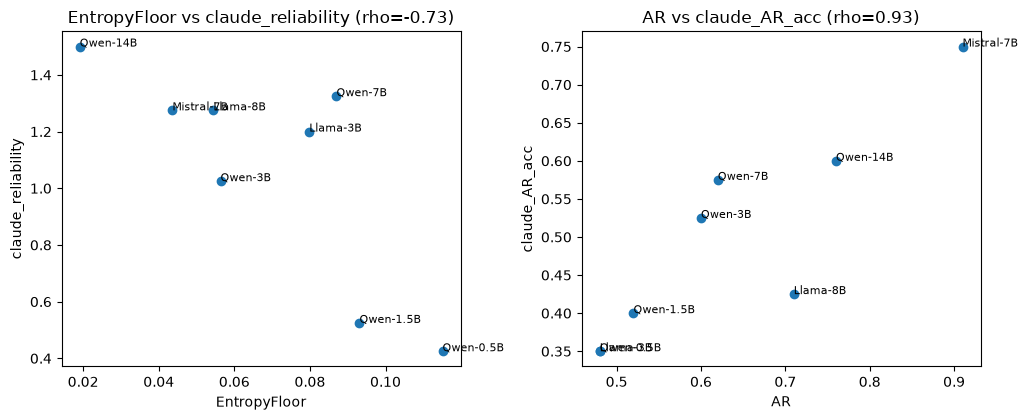

In [14]:
import matplotlib.pyplot as plt
plot_pairs = [("EntropyFloor","claude_reliability"),("AR","claude_AR_acc")]
plot_pairs = [(a,b) for a,b in plot_pairs if b in merged.columns and merged[b].notna().sum()>3]
if plot_pairs:
    fig, axes = plt.subplots(1, len(plot_pairs), figsize=(5.2*len(plot_pairs),4.3))
    if len(plot_pairs)==1: axes=[axes]
    for ax,(a,b) in zip(axes, plot_pairs):
        d = merged[["Model",a,b]].dropna()
        ax.scatter(d[a], d[b])
        for _,r in d.iterrows(): ax.annotate(r["Model"], (r[a],r[b]), fontsize=8)
        rho,_ = spearmanr(d[a], d[b])
        ax.set_xlabel(a); ax.set_ylabel(b); ax.set_title(f"{a} vs {b} (rho={rho:.2f})")
    plt.tight_layout(); plt.savefig("nb2_claude_eval.png", dpi=200); plt.show()